In [ ]:
from imblearn.combine import SMOTEENN
def smotenn(X_train_scaled, y_train):
    smote_enn = SMOTEENN(random_state=42, sampling_strategy='auto')
    X_smote_enn, y_smote_enn = smote_enn.fit_resample(X_train_scaled, y_train)
    return X_smote_enn, y_smote_enn

In [ ]:
from imblearn.over_sampling import BorderlineSMOTE
def borderlineSmote(X_train_scaled, y_train):
    borderline_smote = BorderlineSMOTE(random_state=42, sampling_strategy='auto')
    X_borderline, y_borderline = borderline_smote.fit_resample(X_train_scaled, y_train)
    return X_borderline, y_borderline

In [ ]:
from imblearn.over_sampling import ADASYN
def adasyn(X_train_scaled, y_train):
    adasyn = ADASYN(random_state=42, sampling_strategy='auto')
    X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
    return X_adasyn, y_adasyn

In [ ]:

import numpy as np
import pandas as pd

def corr_preservation(original_X, original_y, synthetic_X, synthetic_y, method="pearson"):
    results = {}

    for c in set(original_y) & set(synthetic_y):
        Co = original_X[original_y==c].corr(method=method)
        Cs = synthetic_X[synthetic_y==c].corr(method=method)
        i, j = np.triu_indices(Co.shape[0], k=1)
        a, b = Co.to_numpy()[i, j], Cs.to_numpy()[i, j]
        r = np.corrcoef(a, b)[0,1] if np.std(a)>0 and np.std(b)>0 else np.nan
        mae = np.mean(np.abs(a - b))

        results[c] =  {"corr_of_corrs": r, "mae": mae}

    return results 

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE

def create_conservative_strategy(y_train):
    """Create conservative sampling strategy limiting minority class augmentation"""
    counts = Counter(y_train)
    majority_class_count = max(counts.values())
    # Limit minority classes to 20% of majority class size
    target_count = int(majority_class_count * 0.2)
    
    conservative_strategy = {}
    for class_label, count in counts.items():
        if count < target_count:
            conservative_strategy[class_label] = target_count
    return conservative_strategy

conservative_strategy = create_conservative_strategy(y_train)
smote_conservative = SMOTE(random_state=42, sampling_strategy=conservative_strategy)
X_conservative, y_conservative = smote_conservative.fit_resample(X_train_scaled, y_train)

In [ ]:
from sklearn.linear_model import LogisticRegression
def train_logist_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    model.set_params(class_weight='balanced')
    model.fit(X_train, y_train)
    return model

In [ ]:
def correlation_preservation_analysis(self, X_synthetic, y_synthetic):
    """
    Analyze preservation of feature correlations in synthetic data
    """
    correlation_results = {}
    
    # Calculate original correlation matrix
    orig_corr = np.corrcoef(self.X_original.T)
    synth_corr = np.corrcoef(X_synthetic.T)
    
    # Handle NaN values that may arise from constant features
    orig_corr = np.nan_to_num(orig_corr, nan=0.0, posinf=1.0, neginf=-1.0)
    synth_corr = np.nan_to_num(synth_corr, nan=0.0, posinf=1.0, neginf=-1.0)
    
    # Calculate correlation matrix distance
    corr_frobenius_distance = np.linalg.norm(orig_corr - synth_corr, 'fro')
    
    # Use a more robust method for spectral norm
    try:
        corr_spectral_distance = np.linalg.norm(orig_corr - synth_corr, 2)
    except np.linalg.LinAlgError:
        # Fallback to Frobenius norm if SVD fails
        corr_spectral_distance = corr_frobenius_distance
    
    # Calculate correlation coefficient between correlation matrices
    orig_corr_flat = orig_corr[np.triu_indices_from(orig_corr, k=1)]
    synth_corr_flat = synth_corr[np.triu_indices_from(synth_corr, k=1)]
    
    # Handle case where correlations are constant
    if np.std(orig_corr_flat) == 0 or np.std(synth_corr_flat) == 0:
        correlation_preservation = 1.0 if np.allclose(orig_corr_flat, synth_corr_flat) else 0.0
    else:
        correlation_preservation = np.corrcoef(orig_corr_flat, synth_corr_flat)[0, 1]
        correlation_preservation = np.nan_to_num(correlation_preservation, nan=0.0)
    
    correlation_results = {
        'frobenius_distance': corr_frobenius_distance,
        'spectral_distance': corr_spectral_distance,
        'correlation_preservation': correlation_preservation,
        'original_correlation_matrix': orig_corr,
        'synthetic_correlation_matrix': synth_corr
    }
    
    return correlation_results

In [ ]:
import numpy as np
from scipy.spatial.distance import jensenshannon

def jensen_shannon_divergence_fixed(X_synthetic, y_synthetic, X_original, y_original):
    js_divergences = {}
    
    for class_label in np.unique(y_original):
        X_orig_class = X_original[y_original == class_label]
        X_synth_class = X_synthetic[y_synthetic == class_label]
            
        feature_js_divs = []
        
        for feature_idx in range(X_original.shape[1]):
            orig_feature = X_orig_class[:, feature_idx]
            synth_feature = X_synth_class[:, feature_idx]
            
            bins = np.linspace(
                min(orig_feature.min(), synth_feature.min()),
                max(orig_feature.max(), synth_feature.max()),
                50
            )
        
            orig_hist, _ = np.histogram(orig_feature, bins=bins, density=True)
            synth_hist, _ = np.histogram(synth_feature, bins=bins, density=True)
            
            orig_hist = orig_hist + 1e-12
            synth_hist = synth_hist + 1e-12
        
            orig_hist = orig_hist / np.sum(orig_hist)
            synth_hist = synth_hist / np.sum(synth_hist)

            js_distance = jensenshannon(orig_hist, synth_hist, base=2)
            js_div = js_distance ** 2
            
            feature_js_divs.append(js_div)
        
        js_divergences[class_label] = {
            'mean_divergence': np.mean(feature_js_divs),
        }
    
    return js_divergences

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/ks_test_flowchart.png'

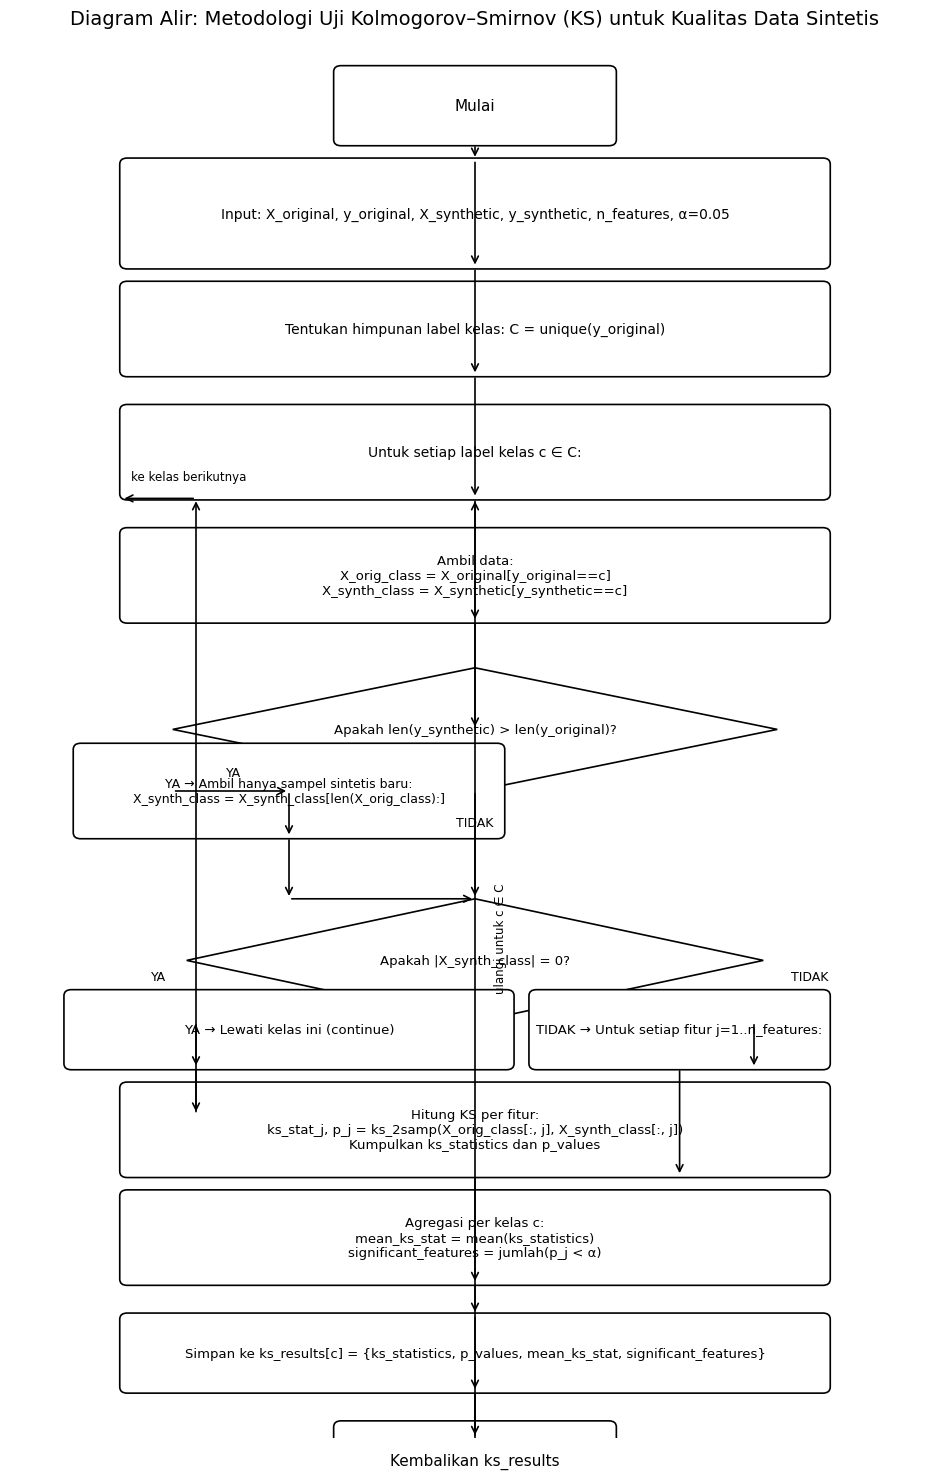

In [ ]:
import numpy as np
from scipy.stats import ks_2samp

def kolmogorov_smirnov_test(X_synthetic, y_synthetic, X_original, y_original):
    ks_results = {}
    for class_label in np.unique(y_original):
        X_orig_class = X_original[y_original == class_label]
        X_synth_class = X_synthetic[y_synthetic == class_label]
        
        feature_ks_stats = []
        feature_p_values = []
        
        for feature_idx in range(X_original.shape[1]):
            orig_feature = X_orig_class[:, feature_idx]
            synth_feature = X_synth_class[:, feature_idx]
            
            # Perform KS test
            ks_stat, p_value = ks_2samp(orig_feature, synth_feature)
            if p_value > 0.05:
                print("Tidak ada perbedaan signifikan antara distribusi data asli dan sintetis.")
            feature_ks_stats.append(ks_stat)
            feature_p_values.append(p_value)

        print(f"rata rata nilai KS pada tiap fitur pada distribusi kumulatif kelas {class_label}: {np.mean(feature_ks_stats)}")
        ks_results[class_label] = np.mean(feature_ks_stats)

    return ks_results
